# Chronic Kidney Disease
The UCI Chronic Kidney Disease (CKD) dataset contains 400 patient records with 25 attributes (11 numeric, 14 categorical) including medical indicators like blood pressure, albumin, serum creatinine, hemoglobin, and comorbidities such as diabetes and hypertension. The goal is to classify patients as CKD or Not CKD using machine learning models.

**Attributes Information:**

* age - age	
* bp  -	blood pressure
* sg  -	specific gravity
* al  -  albumin
* su  -	sugar
* rbc -	red blood cells
* pc  -	pus cell
* pcc -	pus cell clumps
* ba  -	bacteria
* bgr -	blood glucose random
* bu  -	blood urea
* sc  -	serum creatinine
* sod -	sodium
* pot -	potassium
* hemo -	hemoglobin
* pcv  -	packed cell volume
* wc   -	white blood cell count
* rc   -	red blood cell count
* htn  -	hypertension
* dm   -	diabetes mellitus
* cad  -	coronary artery disease
* appet-	appetite
* pe   -	pedal edema
* ane  -	anemia
* classification -	class - Target Variable	

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
data = pd.read_csv("C:\\Users\\rache\\OneDrive\\Rachel Study Materials\\Project Dataset\\Chronic_Kidney_Disease_dataset_ML_Format.csv")

In [3]:
# First Five rows of the dataset
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


In [4]:
#Shape of the dataset
data.shape

(400, 25)

In [5]:
# datatypes
data.dtypes

age                 int64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                 int64
dm                  int64
cad                 int64
appet               int64
pe                  int64
ane                 int64
classification      int64
dtype: object

In [6]:
# Information of the Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    int64  
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int64  
 6   pc              400 non-null    int64  
 7   pcc             400 non-null    int64  
 8   ba              400 non-null    int64  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

In [7]:
# Summary of the dataset
data.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.735000,76.575000,1.017712,0.90000,0.395000,0.882500,0.810000,0.105000,0.055000,145.062500,...,39.082500,8298.500000,4.737750,0.367500,0.34250,0.085000,0.795000,0.190000,0.150000,0.625000
std,16.692104,13.489785,0.005434,1.31313,1.040038,0.322418,0.392792,0.306937,0.228266,75.260774,...,8.162245,2529.593814,0.841439,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519,0.484729
min,2.000000,50.000000,1.005000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.750000,70.000000,1.015000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,101.000000,...,34.000000,6975.000000,4.500000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,54.000000,80.000000,1.020000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,121.000000,...,40.000000,8000.000000,4.800000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,64.000000,80.000000,1.020000,2.00000,0.000000,1.000000,1.000000,0.000000,0.000000,150.000000,...,44.000000,9400.000000,5.100000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,1.000000
max,90.000000,180.000000,1.025000,5.00000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


* **There are No null values or missing values in the dataset**.
* **There is some skewness in some attributes**

In [8]:
# Null values
data.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

# Exploratory Data Analysis

<Axes: title={'center': 'Count of Blood Pressure'}, xlabel='bp', ylabel='Count'>

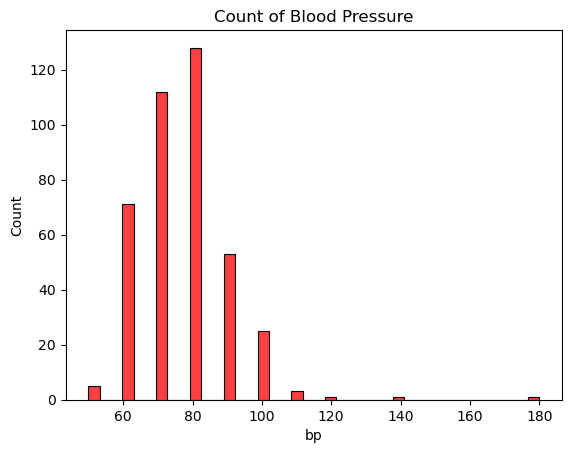

In [9]:
# Histogram of Blood pressure
plt.title("Count of Blood Pressure")
sns.histplot(data["bp"], color = "r")

* From this histogram plot, we clearly see Most of the patients have BP around **80** and secondly **70**.

<Axes: title={'center': 'ScatterPlot of patients whose Age and their Blood Pressure suffering from CKD or Not'}, xlabel='age', ylabel='bp'>

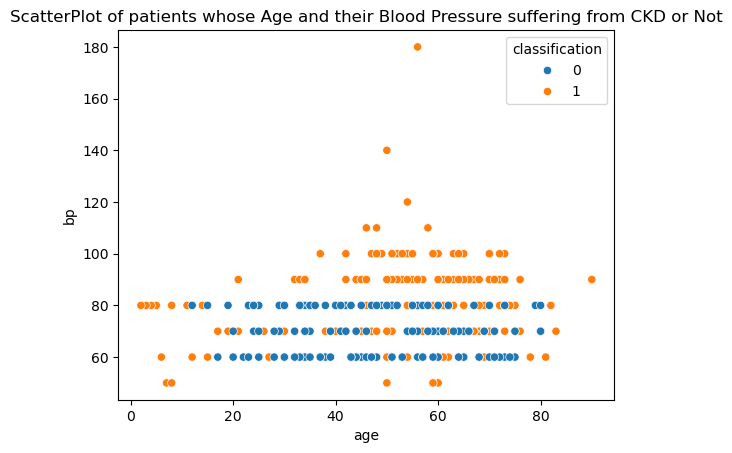

In [10]:
# Scatterplot of Age and their BP who are suffering from CKD or not
plt.title("ScatterPlot of patients whose Age and their Blood Pressure suffering from CKD or Not")
sns.scatterplot(x = data['age'], y = data['bp'], hue = data['classification'])

* Mostly Patients from  40 to 80 age has ckd with BP around **90** and **100.**

<Axes: title={'center': 'Swarmplot Sugar vs blood glucose random with diabetes mellitus'}, xlabel='su', ylabel='bgr'>

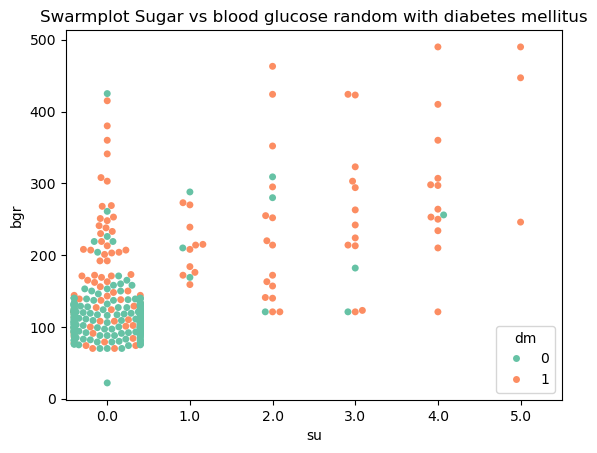

In [11]:
# Swarmplot Sugar vs blood glucose random with diabetes mellitus
plt.title("Swarmplot Sugar vs blood glucose random with diabetes mellitus")
sns.swarmplot(x='su', y='bgr', data=data, hue = "dm", palette = 'Set2')

* Most of the patients who are not having diabetes has blood glucose random around 90 to 150.
* But Most of the ckd patients are suffering for Diabetes mellitus has High Sugar levels with High Blood glucose random.

<Axes: title={'center': 'Sodium vs Serum Creatinine with Pus cells'}, xlabel='sod', ylabel='sc'>

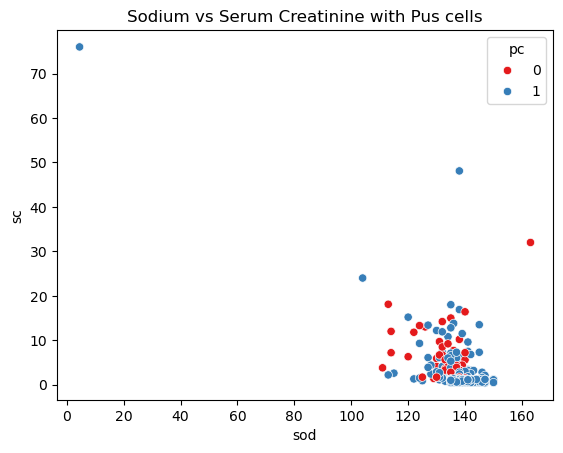

In [12]:
# Sodium vs Serum Creatinine with Pus cells
plt.title("Sodium vs Serum Creatinine with Pus cells")
sns.scatterplot(x = 'sod', y = 'sc', data = data, hue = 'pc', palette = 'Set1')

* Mostly patients has high sodium levels has creatine has 5 to 20 and has pus cells. 

<Axes: title={'center': 'Barplot coronary artery disease and hypertension with pedel edema'}, xlabel='cad', ylabel='htn'>

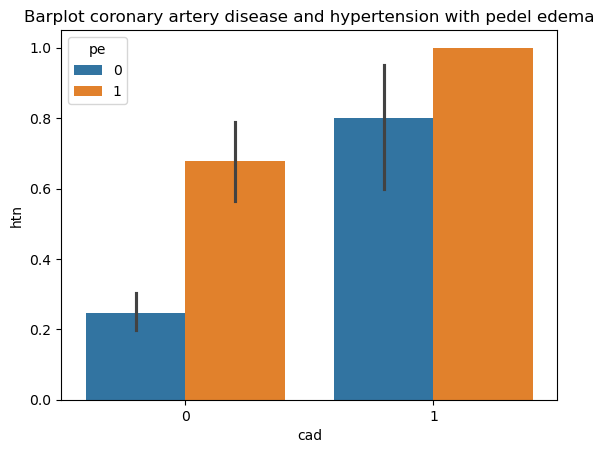

In [13]:
# Barplot coronary artery disease and hypertension with pedel edema
plt.title("Barplot coronary artery disease and hypertension with pedel edema")
sns.barplot(x = 'cad', y = 'htn', data = data, hue = 'pe')

* Patients with ckd who has Coronary Artery Disease are likely have hypertension and has pedel edema.

<Axes: title={'center': 'scatterplot of patients Age who has coronary artery disease with classification'}, xlabel='age', ylabel='cad'>

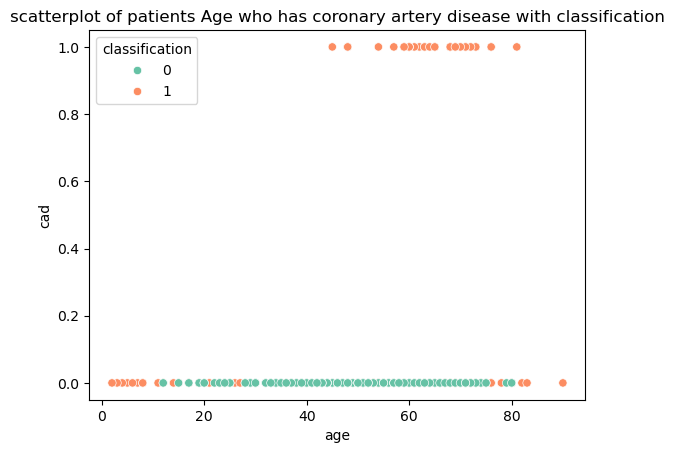

In [14]:
# scatterplot of patients Age who has coronary artery disease with classification
plt.title("scatterplot of patients Age who has coronary artery disease with classification")
sns.scatterplot(x = 'age', y = 'cad', data = data, hue = 'classification', palette = 'Set2')

* we can see Most of the patients with CKD are not suffering from CAD.
* Mostly Patients from 40 to 80 ages has ckd with Coronary Artery Disease. 

# Data Preprocessing
Let's check the skewness and outliers

In [15]:
data.skew()

age               -0.654884
bp                 1.601858
sg                -0.333320
al                 1.180088
su                 2.700055
rbc               -2.384616
pc                -1.586375
pcc                2.586749
ba                 3.918557
bgr                2.204143
bu                 2.724138
sc                 7.665610
sod               -7.929336
pot               13.132548
hemo              -0.376747
pcv               -0.548541
wc                 2.001895
rc                -0.330485
htn                0.551722
dm                 0.666294
cad                2.987387
appet             -1.466982
pe                 1.586375
ane                1.967779
classification    -0.518344
dtype: float64

* blood pressure(bp), albumin(al), sugar(su), blood gulcose random(bgr), blood urea(bu), white blood cell(wc) are **moderately right skewed**.
* Serum Creatinine(sc), sodium(sod), potassium(pot) are **Extremely skewed**.
* Sodium(sod) is **Extremely Left Skewed**.

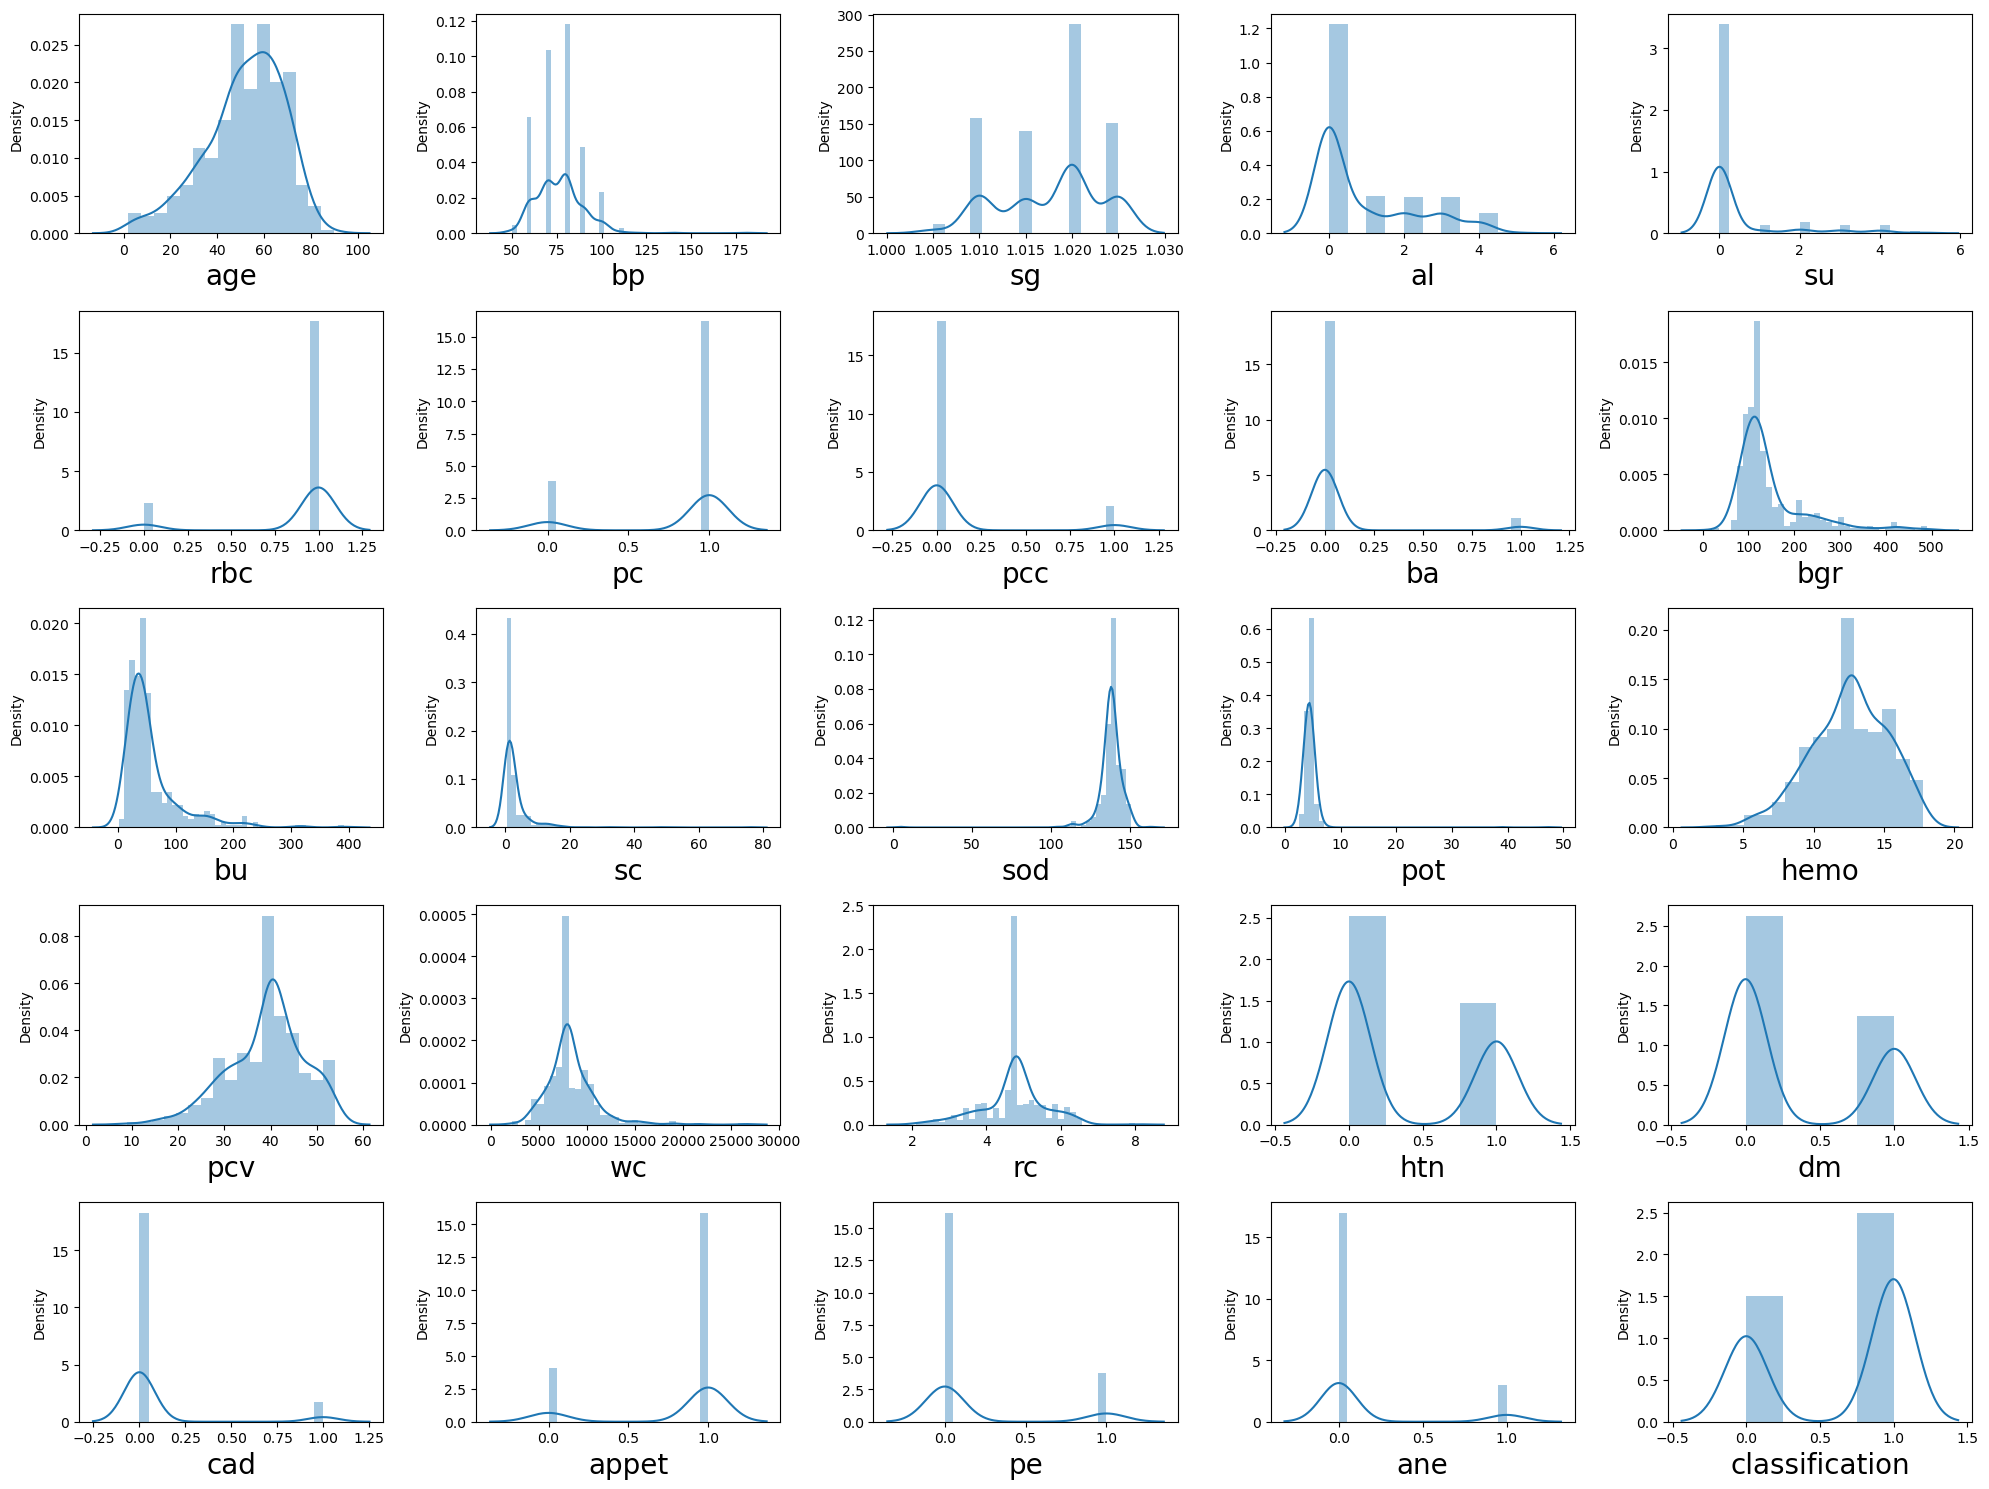

In [16]:
# Checking the Skewness 
plt.figure(figsize=(20,15))
plotnumber=1
for column in data:
    if plotnumber<=25:
        ax=plt.subplot(5,5,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

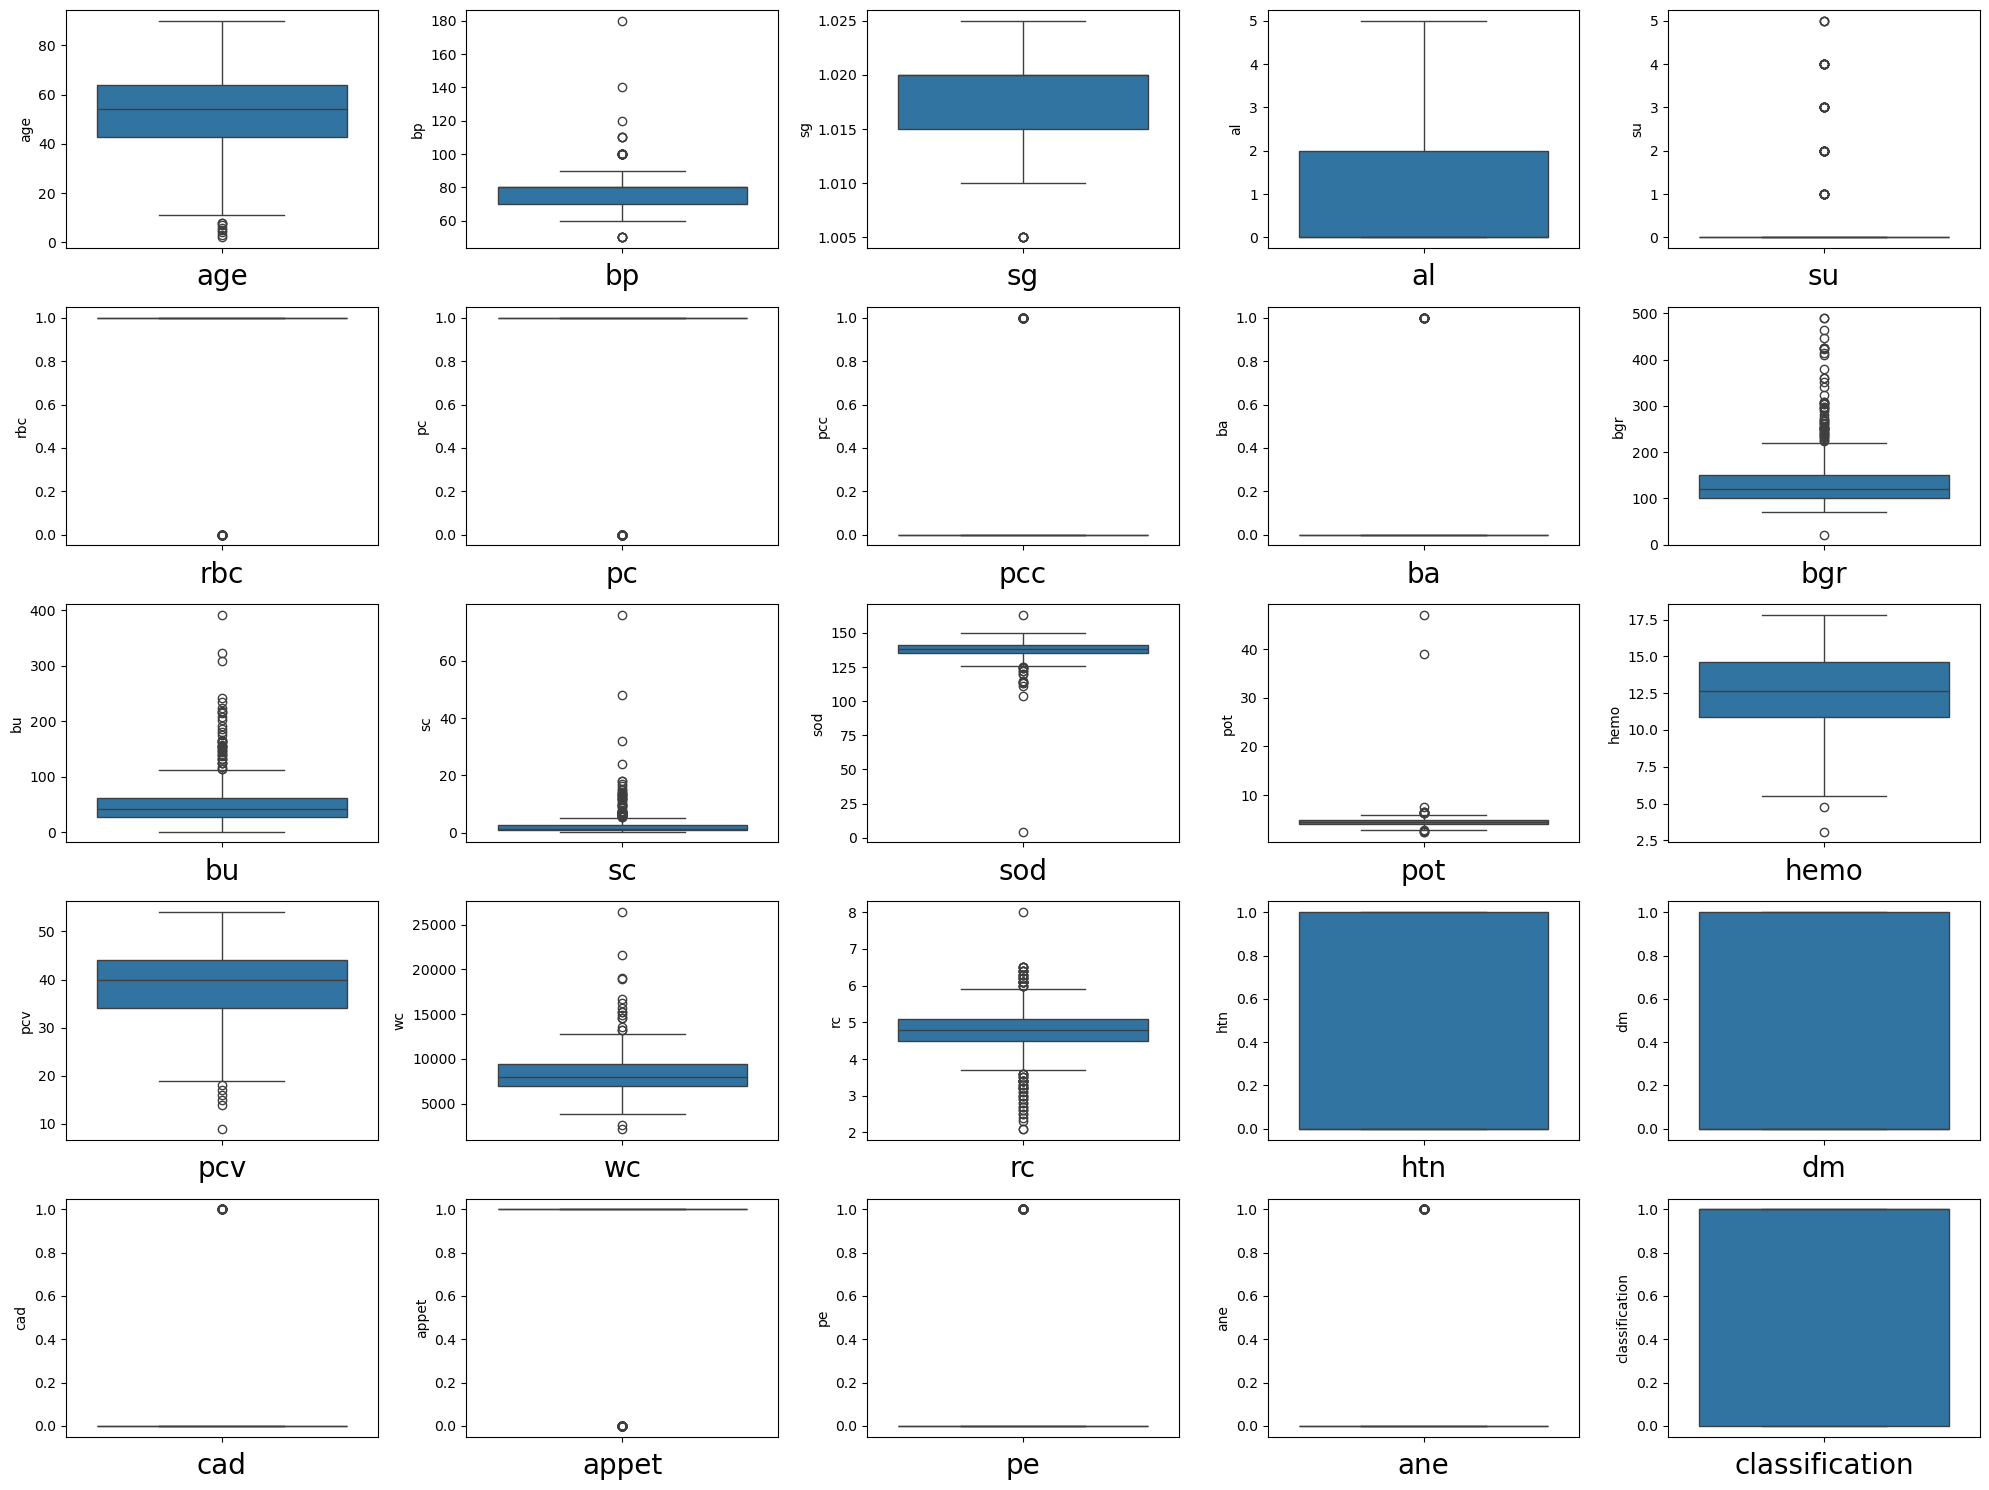

In [17]:
# Check the outliers
plt.figure(figsize=(20,15))
plotnumber=1
for column in data:
    if plotnumber<=25:
        ax=plt.subplot(5,5,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

In [18]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


In [19]:
data.dtypes

age                 int64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                 int64
dm                  int64
cad                 int64
appet               int64
pe                  int64
ane                 int64
classification      int64
dtype: object

In [20]:
(data == 0).sum()

age                 0
bp                  0
sg                  0
al                245
su                339
rbc                47
pc                 76
pcc               358
ba                378
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                 0
wc                  0
rc                  0
htn               253
dm                263
cad               366
appet              82
pe                324
ane               340
classification    150
dtype: int64

* There are no zero values in continous variables.


In [21]:
# # Treat the Outliers
# Let's find the IQR (Inter-Quartile Range) to identify the outliers

In [22]:
#1st Quantile
q1 = data.quantile(0.25)

In [23]:
#3rd Quantile
q3 = data.quantile(0.75)

In [24]:
# IQR Range
IQR = q3 - q1

In [25]:
print("1st Quantile:")
print(q1)
print(" ")
print("3rd Quantile:")
print(q3)
print(" ")
print("Inter Quartile Range:")
print(IQR)

1st Quantile:
age                 42.750
bp                  70.000
sg                   1.015
al                   0.000
su                   0.000
rbc                  1.000
pc                   1.000
pcc                  0.000
ba                   0.000
bgr                101.000
bu                  27.000
sc                   0.900
sod                135.000
pot                  4.000
hemo                10.875
pcv                 34.000
wc                6975.000
rc                   4.500
htn                  0.000
dm                   0.000
cad                  0.000
appet                1.000
pe                   0.000
ane                  0.000
classification       0.000
Name: 0.25, dtype: float64
 
3rd Quantile:
age                 64.000
bp                  80.000
sg                   1.020
al                   2.000
su                   0.000
rbc                  1.000
pc                   1.000
pcc                  0.000
ba                   0.000
bgr                150.00

### *Outliers Detection Formula*

#### ***Upper Limit:*** Q3 +(1.5 * IQR)


#### ***Lower Limit:*** Q1 -(1.5 * IQR)

In [26]:
# blood pressure(bp), albumin(al), sugar(su), blood gulcose random(bgr), blood urea(bu), white blood cell(wc) are moderately right skewed.
# Serum Creatinine(sc), sodium(sod), potassium(pot) are Extremely skewed.
# Sodium(sod) is Extremely Left Skewed.

In [27]:
# Validating blood pressure outlier
bp_pred_high = (q3.bp + (1.5 * IQR.bp))
bp_pred_high

np.float64(95.0)

In [28]:
#Check the indexes which have higher values
index=np.where(data['bp']>bp_pred_high)
index

(array([  8,  18,  24,  33,  42,  51,  59,  73,  87,  88,  90,  93,  98,
         99, 107, 124, 133, 134, 146, 192, 196, 198, 210, 211, 217, 226,
        233, 234, 238, 245, 246]),)

In [29]:
data['bp'] = np.sqrt(data['bp'])

In [30]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,8.944272,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7,7.071068,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62,8.944272,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48,8.366600,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51,8.944272,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


<Axes: xlabel='bp', ylabel='Density'>

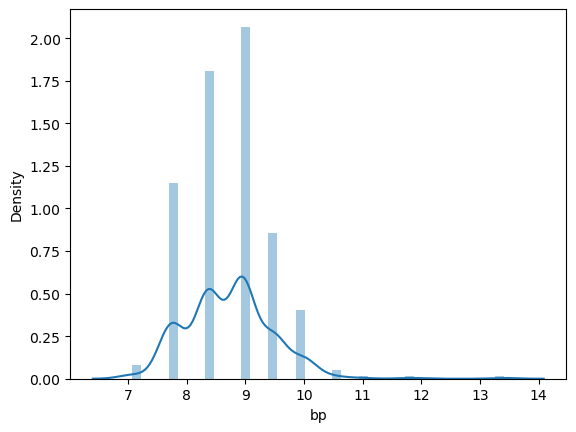

In [31]:
sns.distplot(data['bp'])

In [32]:
# Validating albumin outlier
al_pred_high = (q3.al + (1.5 * IQR.al))
al_pred_high

np.float64(5.0)

In [33]:
#Check the indexes which have higher values
index=np.where(data['al']>al_pred_high)
index

(array([], dtype=int64),)

In [34]:
data['al'] = np.sqrt(data['al'])

In [35]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,8.944272,1.020,1.000000,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7,7.071068,1.020,2.000000,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62,8.944272,1.010,1.414214,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48,8.366600,1.005,2.000000,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51,8.944272,1.010,1.414214,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


<Axes: xlabel='al', ylabel='Density'>

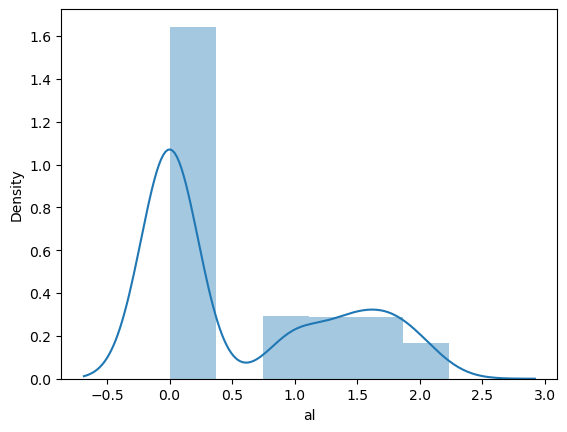

In [36]:
sns.distplot(data['al'])

In [37]:
#Validating Sugar outlier
su_pred_high = (q3.su + (1.5 * IQR.su))
su_pred_high

np.float64(0.0)

In [38]:
#Check the indexes which have higher values
index=np.where(data['su']>su_pred_high)
index

(array([  2,   7,  10,  12,  14,  18,  27,  28,  32,  35,  39,  53,  54,
         56,  61,  69,  70,  72,  90,  91,  93,  96,  99, 107, 111, 113,
        120, 123, 128, 135, 140, 143, 146, 147, 153, 154, 158, 165, 168,
        169, 170, 172, 177, 180, 184, 189, 195, 198, 204, 210, 212, 213,
        223, 225, 226, 237, 242, 243, 244, 248, 249]),)

In [39]:
data['su'] = np.log1p(data['su'])

In [40]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,8.944272,1.020,1.000000,0.000000,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7,7.071068,1.020,2.000000,0.000000,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62,8.944272,1.010,1.414214,1.386294,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48,8.366600,1.005,2.000000,0.000000,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51,8.944272,1.010,1.414214,0.000000,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


<Axes: xlabel='su', ylabel='Density'>

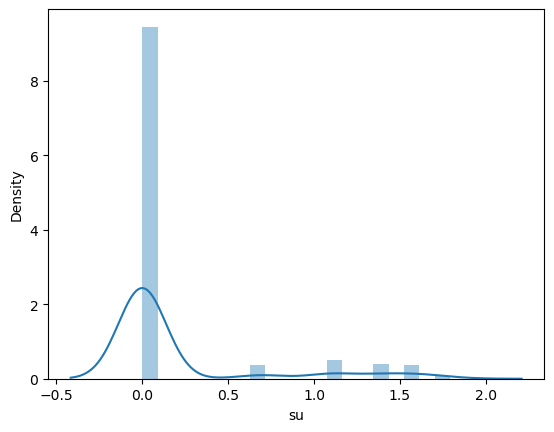

In [41]:
sns.distplot(data['su'])

In [42]:
#Validating Blood glucose Random outlier
bgr_pred_high = (q3.bgr + (1.5 * IQR.bgr))
bgr_pred_high

np.float64(223.5)

In [43]:
#Check the indexes which have higher values
index=np.where(data['bgr']>bgr_pred_high)
index

(array([  2,   7,  10,  11,  18,  27,  35,  53,  58,  67,  69,  70,  81,
         86,  88,  90,  93,  99, 103, 107, 109, 111, 120, 125, 128, 137,
        140, 147, 153, 154, 158, 159, 168, 170, 172, 175, 180, 184, 189,
        198, 207, 208, 210, 212, 219, 221, 223, 225, 229, 231, 244, 248]),)

In [44]:
data['bgr'] = np.log1p(data['bgr'])

In [45]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,8.944272,1.020,1.000000,0.000000,1,1,0,0,4.804021,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7,7.071068,1.020,2.000000,0.000000,1,1,0,0,4.804021,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62,8.944272,1.010,1.414214,1.386294,1,1,0,0,6.049733,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48,8.366600,1.005,2.000000,0.000000,1,0,1,0,4.770685,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51,8.944272,1.010,1.414214,0.000000,1,1,0,0,4.672829,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


<Axes: xlabel='bgr', ylabel='Density'>

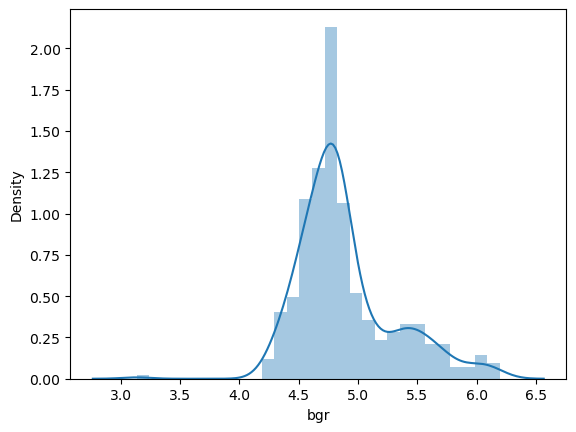

In [46]:
sns.distplot(data['bgr'])

<Axes: ylabel='bgr'>

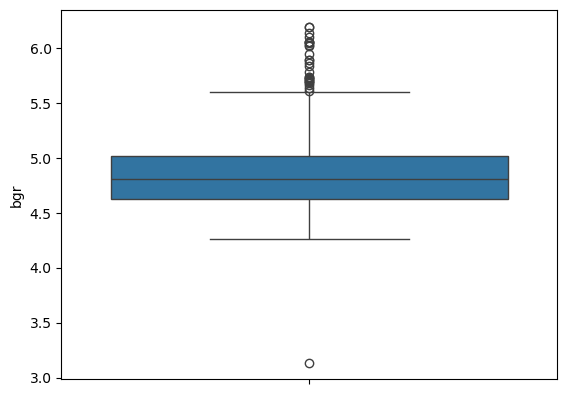

In [47]:
sns.boxplot(data['bgr'])

In [48]:
#Validating blood urea Outlier
bu_pred_high = (q3.bu + (1.5 * IQR.bu))
bu_pred_high

np.float64(113.875)

In [49]:
#Check the indexes which have higher values
index=np.where(data['bu']>bu_pred_high)
index

(array([ 15,  20,  21,  22,  30,  34,  43,  50,  56,  57,  58,  61,  76,
         84, 103, 106, 122, 126, 127, 128, 130, 132, 133, 142, 143, 145,
        153, 154, 174, 177, 178, 184, 191, 193, 196, 210, 212, 229, 238,
        246, 249]),)

In [50]:
data['bu'] = np.log1p(data['bu'])

In [51]:
data['bu'].head()

0    3.610918
1    2.944439
2    3.988984
3    4.043051
4    3.295837
Name: bu, dtype: float64

<Axes: xlabel='bu', ylabel='Density'>

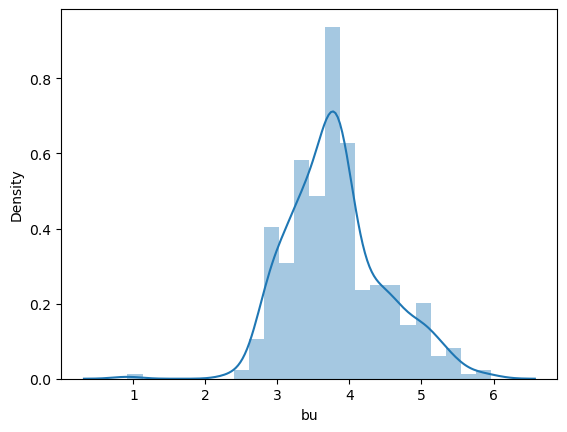

In [52]:
sns.distplot(data['bu'])

<Axes: ylabel='bu'>

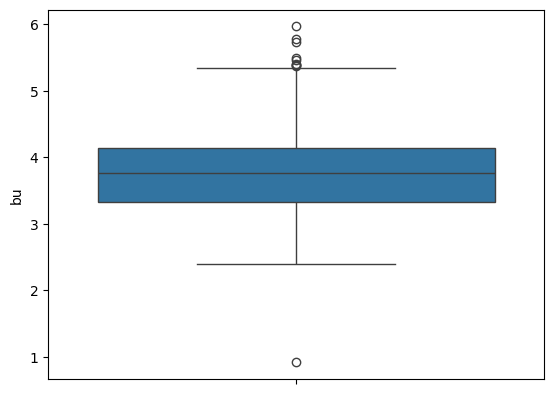

In [53]:
sns.boxplot(data['bu'])

In [54]:
#Validating serum creatinine outlier
sc_pred_high = (q3.sc + (1.5 * IQR.sc))
sc_pred_high

np.float64(5.4625)

In [55]:
#Check the indexes which have higher values
index=np.where(data['sc']>sc_pred_high)
index

(array([  6,   9,  15,  21,  22,  30,  43,  44,  45,  56,  57,  59,  61,
         63,  73,  74,  76,  84,  93,  98, 103, 105, 106, 122, 128, 130,
        132, 134, 141, 142, 143, 145, 148, 153, 154, 173, 174, 183, 191,
        193, 196, 197, 201, 203, 204, 210, 212, 226, 229, 238, 242, 246,
        249]),)

In [56]:
data['sc'] = np.log1p(data['sc'])

<Axes: xlabel='sc', ylabel='Density'>

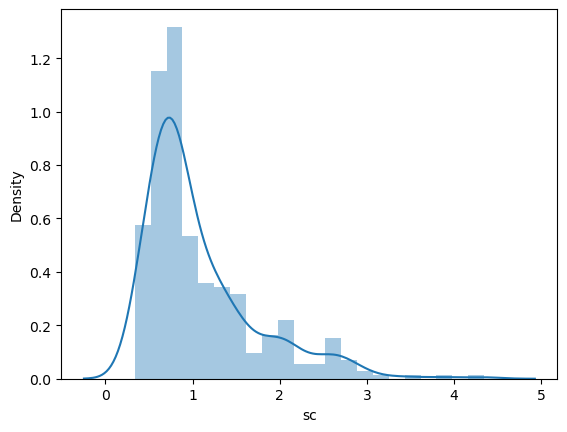

In [57]:
sns.distplot(data['sc'])

<Axes: ylabel='sc'>

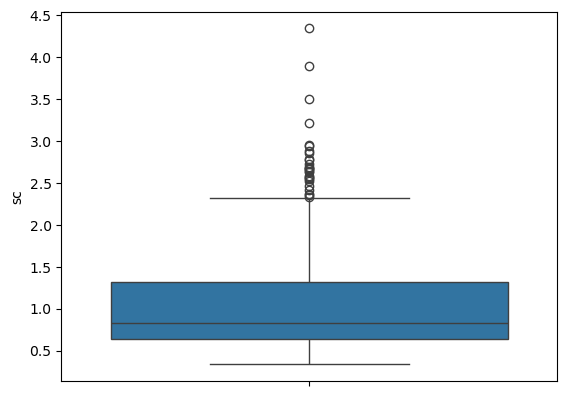

In [58]:
sns.boxplot(data['sc'])

In [59]:
#Validating sodium outlier
sod_pred_low = (q1.sod - (1.5 * IQR.sod))
sod_pred_low

np.float64(126.0)

In [60]:
#Check the indexes which have higher values
index=np.where(data['sod']<sod_pred_low)
index

(array([  3,   6,   9,  21,  48, 159, 162, 171, 175, 176, 193, 196, 197,
        229, 242, 246, 249]),)

In [61]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

data[['sod']] = pt.fit_transform(data[['sod']])

<Axes: xlabel='sod', ylabel='Density'>

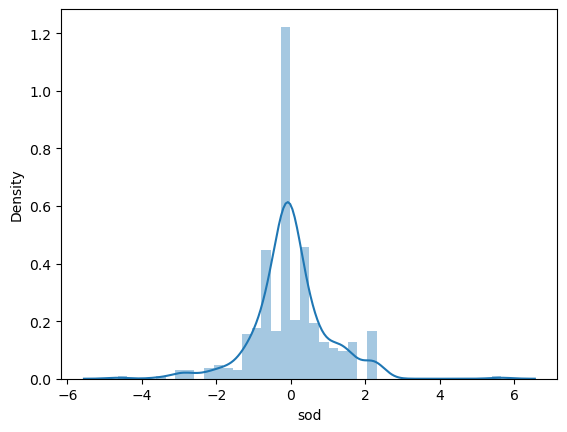

In [62]:
sns.distplot(data['sod'])

<Axes: ylabel='sod'>

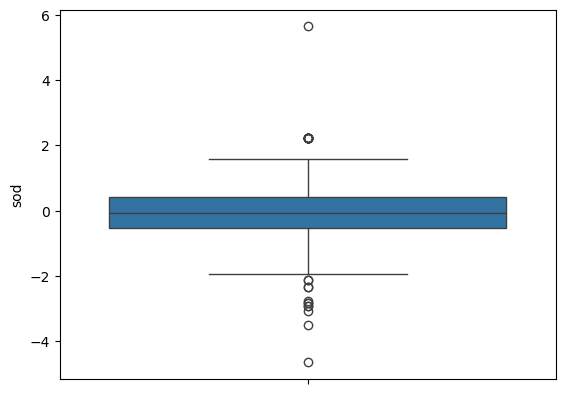

In [63]:
sns.boxplot(data['sod'])

In [64]:
#Validating potassium outlier
pot_pred_high = (q3.pot + (1.5 * IQR.pot))
pot_pred_high

np.float64(6.0)

In [65]:
#Check the indexes which have higher values
index=np.where(data['pot']>pot_pred_high)
index

(array([ 14,  60,  61,  84, 128, 136, 193, 204, 245, 249]),)

In [66]:
data['pot'] = np.log1p(data['pot'])

<Axes: xlabel='pot', ylabel='Density'>

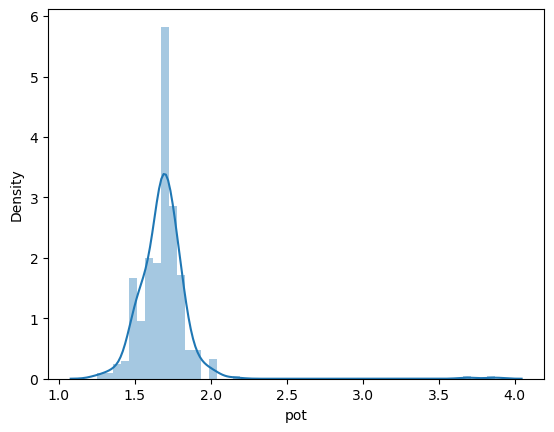

In [67]:
sns.distplot(data['pot'])

<Axes: ylabel='pot'>

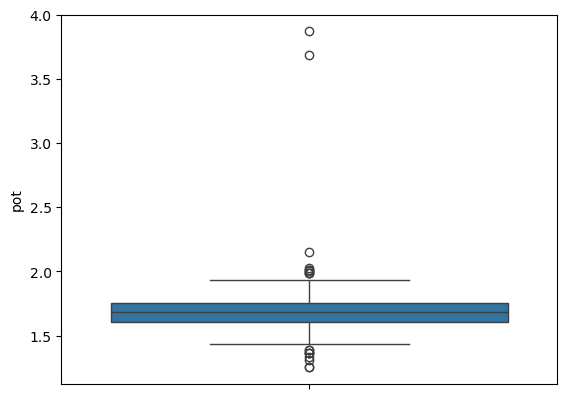

In [68]:
sns.boxplot(data['pot'])

In [69]:
#Validating White Blood cells outlier
wc_pred_high = (q3.wc + (1.5 * IQR.wc))
wc_pred_high

np.float64(13037.5)

In [70]:
#Check the indexes which have higher values
index=np.where(data['wc']>wc_pred_high)
index

(array([ 48,  49,  71,  88, 107, 123, 127, 130, 132, 147, 153, 181, 190,
        198, 229]),)

In [71]:
data['wc'] = np.log1p(data['wc'])

<Axes: xlabel='wc', ylabel='Density'>

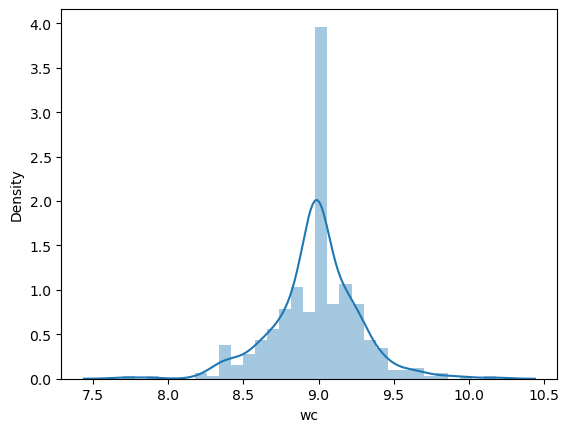

In [72]:
sns.distplot(data["wc"])

<Axes: ylabel='wc'>

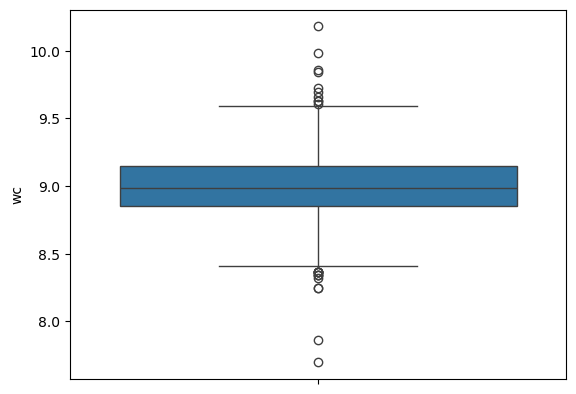

In [73]:
sns.boxplot(data["wc"])

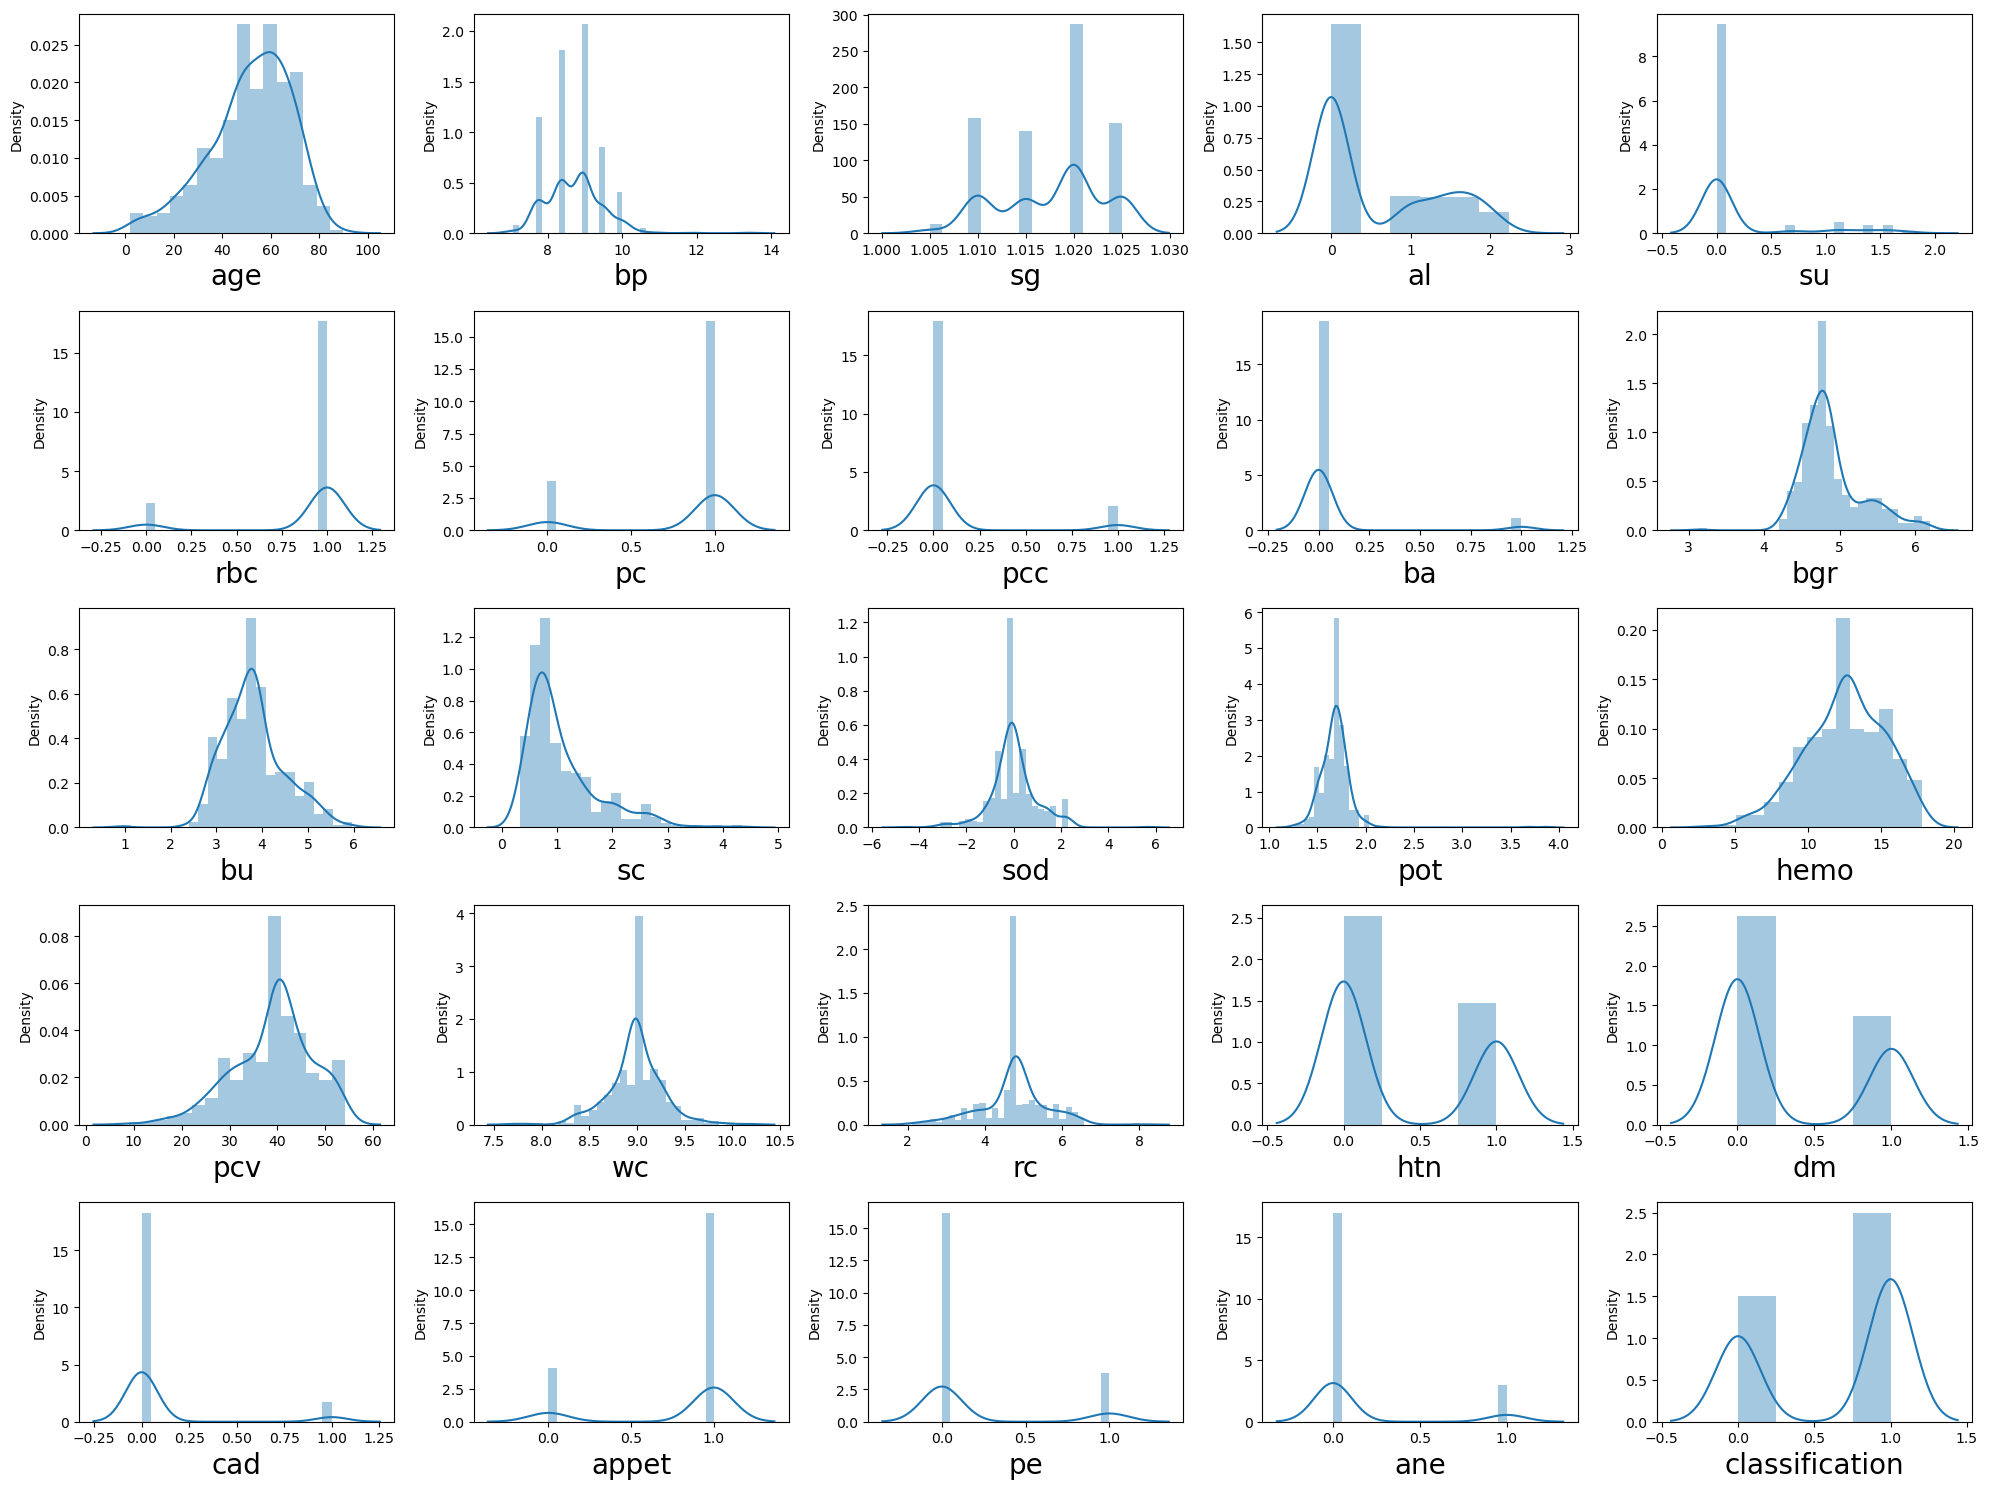

In [74]:
# Checking the Skewness after treating outliers
plt.figure(figsize=(20,15))
plotnumber=1
for column in data:
    if plotnumber<=25:
        ax=plt.subplot(5,5,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

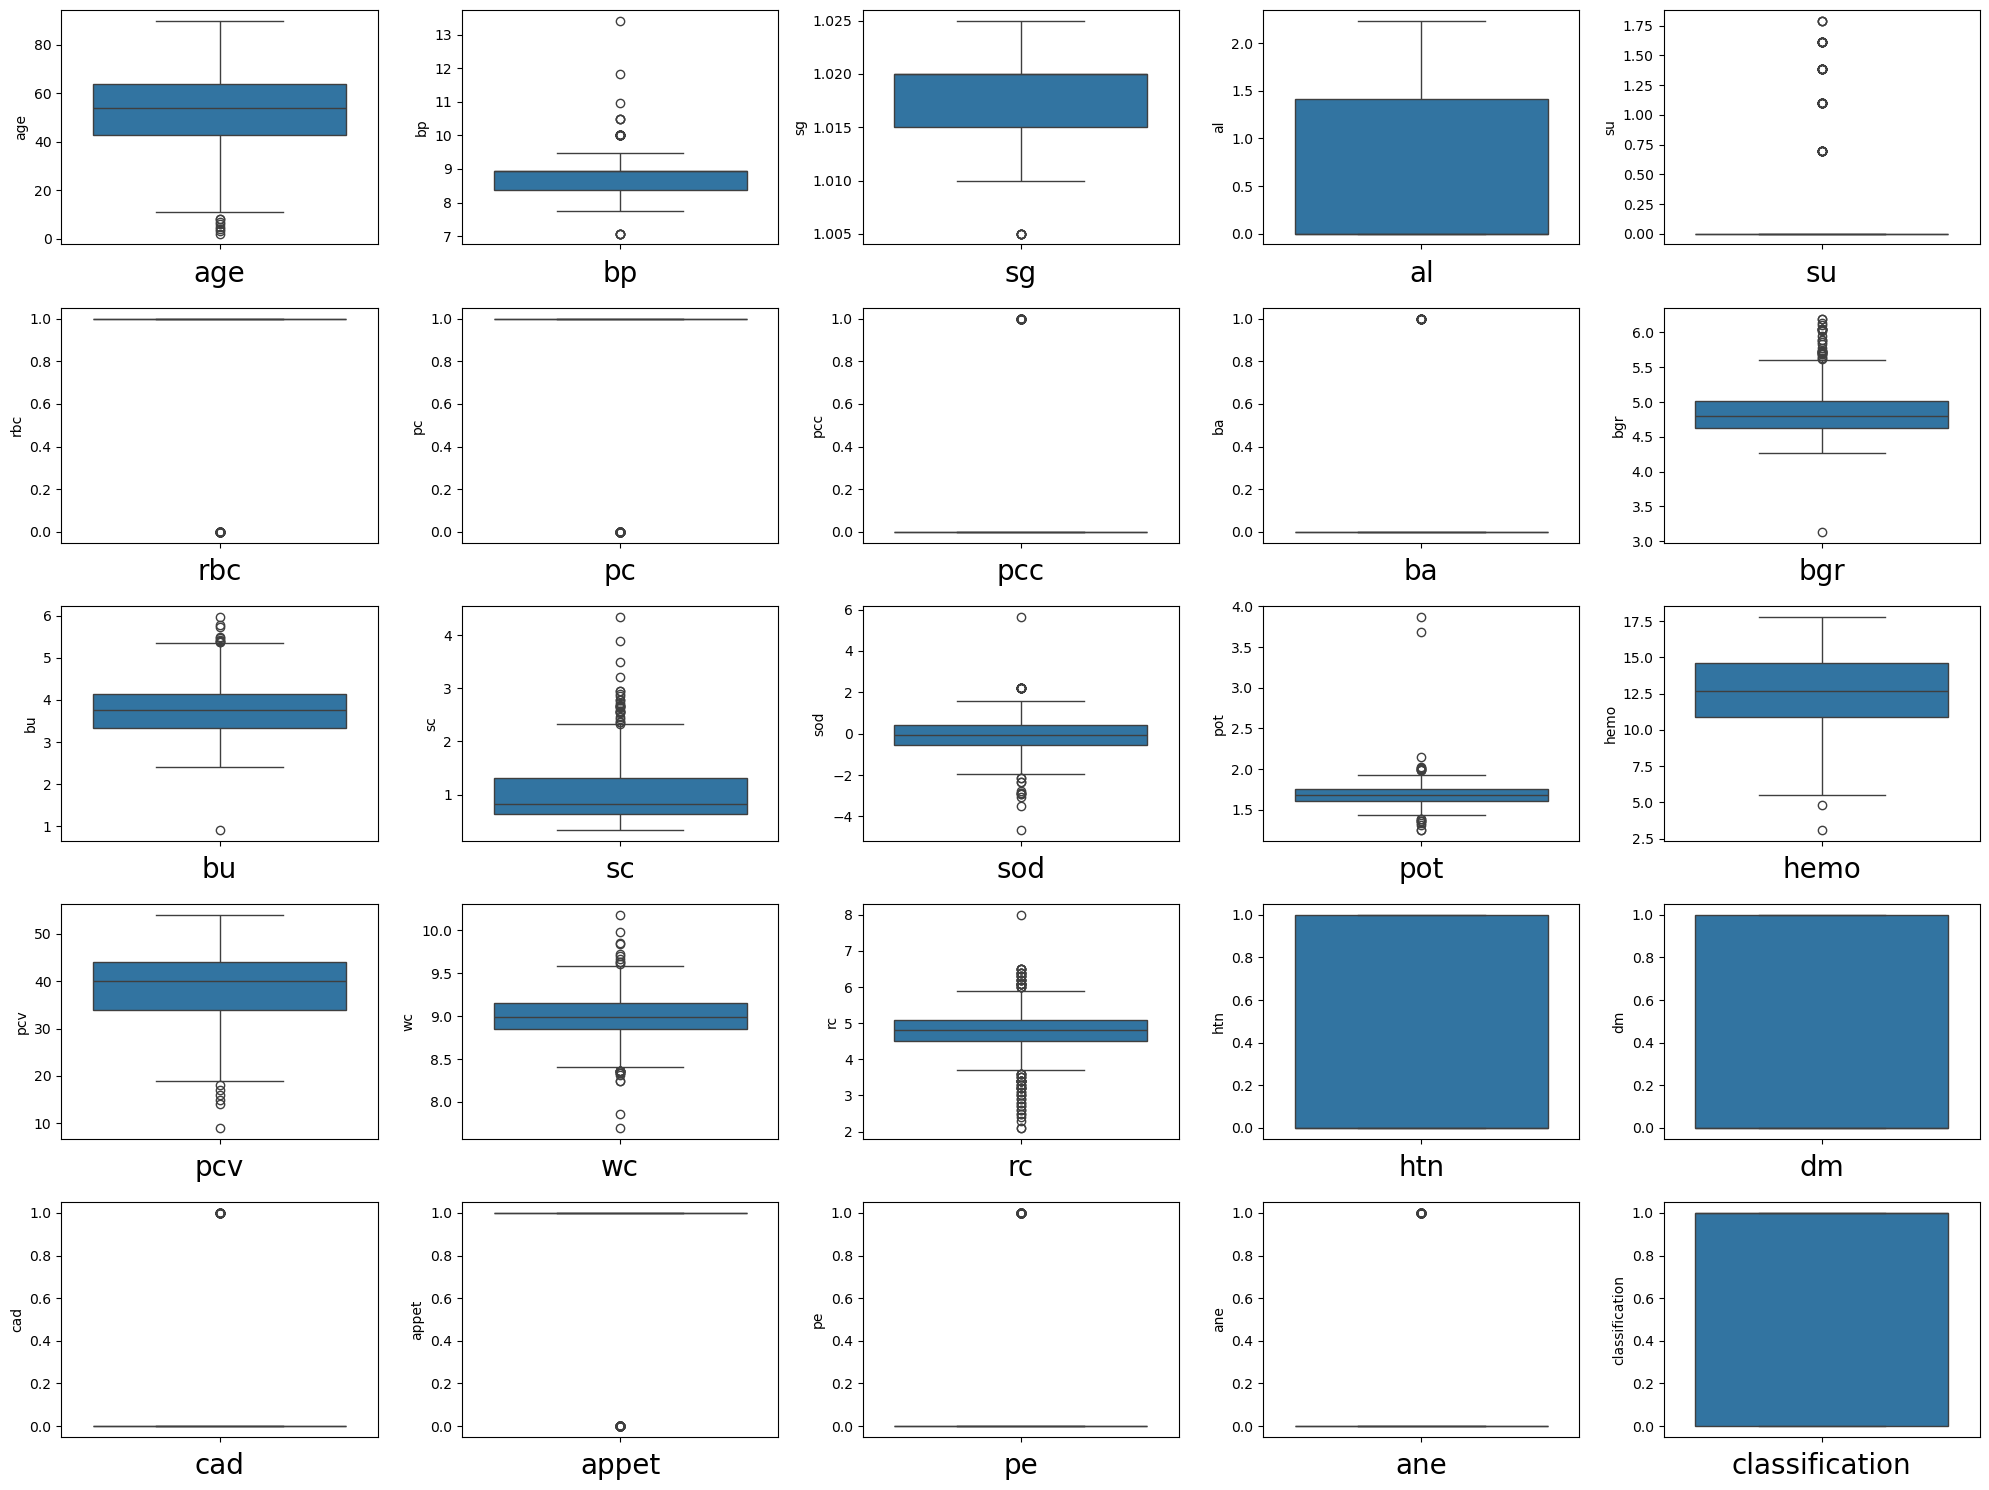

In [75]:
# Check the outliers
plt.figure(figsize=(20,15))
plotnumber=1
for column in data:
    if plotnumber<=25:
        ax=plt.subplot(5,5,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.tight_layout()

* We can clearly see the difference before skewness and after skewness treated in the numerical and continuous variables.
* Let's understand how skewness is treated.
* Since it is a medical dataset, we refrain from aggressive outlier reduction, in order to avoid losing important information.
* ***blood pressure(bp), albumin(al),*** we used **sqrt transformation** for mild right skewness.
* ***sugar(su), blood gulcose random(bgr), blood urea(bu), white blood cell(wc),*** we used **Log Transformation**  for the moderately right skewed attributes.
* ***Serum Creatinine(sc), potassium(pot)*** are Extremely skewed, we used **Log Transformation.**
* ***Sodium(sod)*** is Extremely Left Skewed, we used **Power Transformer(yeo-johnson)** method for treating outliers.

## Multicollinearity Problem

In [76]:
data_corr = data.corr()

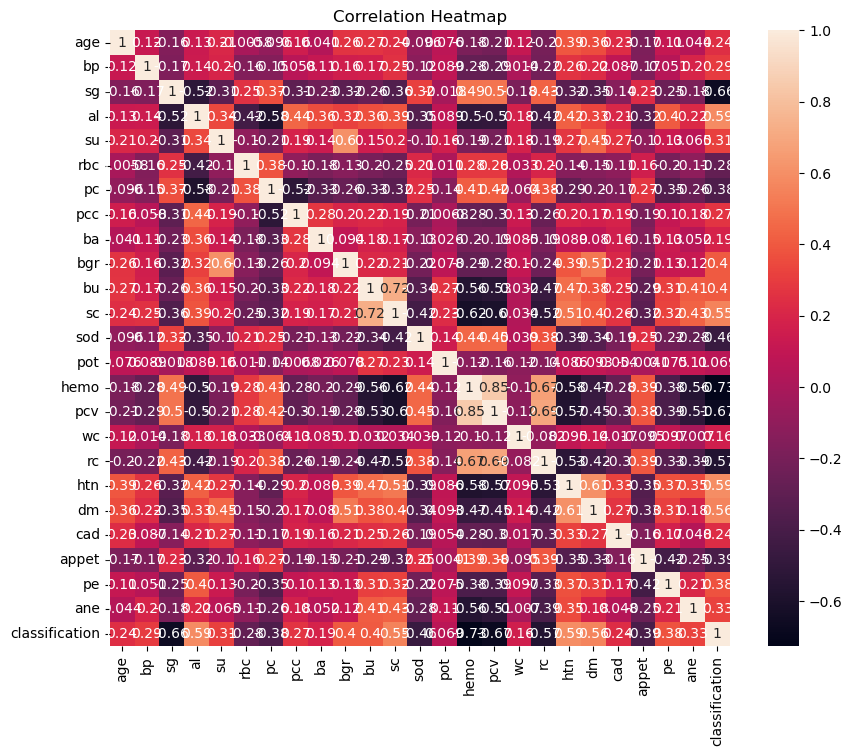

In [77]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data_corr,
    annot=True,
)

plt.title("Correlation Heatmap")
plt.show()

* From the heatmap correlation matrix, we clearly see there are no attributes are extremely correlated with each other.
* But from hemo and pcv they are highly correlated with each other around 85%.
* If needed we can drop a either one column for better model performance.

In [78]:
# Saving the dataset in csv
data.to_csv('Cleaned_Chronic_Kidney_Disease_Dataset.csv', index=False)

In [79]:
df = pd.read_csv('Cleaned_Chronic_Kidney_Disease_Dataset.csv')

In [80]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,8.944272,1.020,1.000000,0.000000,1,1,0,0,4.804021,...,44.0,8.962007,5.2,1,1,0,1,0,0,1
1,7,7.071068,1.020,2.000000,0.000000,1,1,0,0,4.804021,...,38.0,8.699681,4.8,0,0,0,1,0,0,1
2,62,8.944272,1.010,1.414214,1.386294,1,1,0,0,6.049733,...,31.0,8.922792,4.8,0,1,0,0,0,1,1
3,48,8.366600,1.005,2.000000,0.000000,1,0,1,0,4.770685,...,32.0,8.810012,3.9,1,0,0,0,1,1,1
4,51,8.944272,1.010,1.414214,0.000000,1,1,0,0,4.672829,...,35.0,8.895767,4.6,0,0,0,1,0,0,1


In [81]:
df.shape

(400, 25)